![alt text](image-1.png)

# 5장. 선형 회귀 모델: 먼저 긋고 수정하기

[<img src="https://raw.githubusercontent.com/taehojo/taehojo.github.io/master/assets/images/linktocolab.png" align="left"/> ](https://colab.research.google.com/github/taehojo/deeplearning/blob/master/colab/ch05-colab.ipynb)

## 2. 파이썬 코딩으로 확인하는 선형 회귀

### 1.환경 준비

In [3]:
# #matplotlib 라이브러리를 설치합니다.
# !pip install matplotlib 

In [4]:
import numpy as np
import matplotlib.pyplot as plt

### 2. 데이터 준비

In [5]:
#공부 시간 X와 성적 Y의 넘파이 배열을 만듭니다.
x = np.array([2, 4, 6, 8])
y = np.array([81, 93, 91, 97]) 

### 3. 데이터 분포 확인

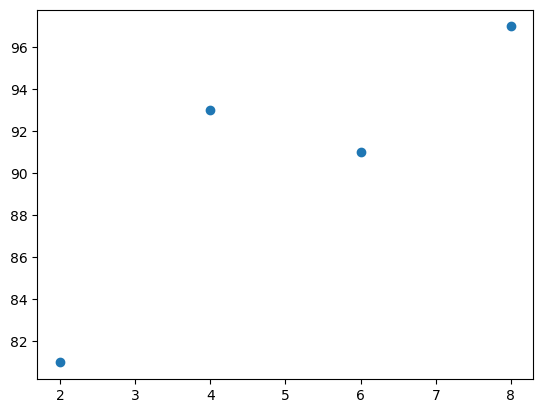

In [6]:
# 데이터의 분포를 그래프로 나타냅니다.
plt.scatter(x, y)
plt.show()

### 4. 실행을 위한 변수 설정

In [7]:
# 기울기 a와 절편 b의 값을 초기화합니다.
a = 0
b = 0

#학습률을 정합니다.
lr = 0.03

#몇 번 반복될지를 설정합니다. 
epochs = 2001 

### 5. 경사 하강법

# 📉 경사하강법(Gradient Descent) 코드 해석

---

## ✅ 전체 목표

우리는 다음 오차 함수를 최소화하려고 한다:

```
SSE = (1/n) ∑ (y - (ax + b))²
```

👉 목표:
**기울기(a), 절편(b)를 찾아서 오차를 최소화**

---

## ✅ 1️⃣ 초기값 설정

```python
a = 0
b = 0
```

👉 시작점 (아무 값이나 가능)

---

## ✅ 2️⃣ 학습률 & 반복 횟수

```python
lr = 0.03
epochs = 2001
```

* `lr` (learning rate) 👉 이동 크기
* `epochs` 👉 반복 횟수

---

## ✅ 3️⃣ 데이터 개수

```python
n = len(x)
```

👉 평균 계산에 사용

---

## ✅ 4️⃣ 반복 시작

```python
for i in range(epochs):
```

👉 반복하면서 점점 최적값으로 이동

---

## ✅ 5️⃣ 예측값 계산

```python
y_pred = a * x + b
```

👉 현재 직선으로 예측값 생성

---

## ✅ 6️⃣ 오차 계산

```python
error = y - y_pred
```

👉 실제값 - 예측값

---

## ✅ 7️⃣ 기울기(a)에 대한 미분

```python
a_diff = (2/n) * sum(-x * (error))
```

수식으로 보면:

```
∂/∂a = -(2/n) ∑ x (y - (ax + b))
```

👉 의미:

* x 값이 클수록 영향 큼
* 오차가 클수록 더 많이 수정됨

---

## ✅ 8️⃣ 절편(b)에 대한 미분

```python
b_diff = (2/n) * sum(-(error))
```

수식:

```
∂/∂b = -(2/n) ∑ (y - (ax + b))
```

---

## ✅ 9️⃣ 파라미터 업데이트 (핵심)

```python
a = a - lr * a_diff
b = b - lr * b_diff
```

👉 의미:

> “오차가 줄어드는 방향으로 조금 이동”

* 미분값 = 증가 방향
* 우리는 최소값 찾기 → 반대로 이동

---

## 🔟 중간 결과 출력

```python
if i % 100 == 0:
    print(...)
```

👉 학습 진행 상황 확인

---

## 🔁 전체 흐름

```
초기값 → 예측 → 오차 계산 → 미분 → 업데이트 → 반복
```

---

## 💡 직관적 이해

* 처음엔 엉뚱한 직선
* 오차 계산
* 조금 수정
* 반복

👉 결국:

> 오차가 최소가 되는 직선에 수렴

---

## 🎯 핵심 포인트

1. **error → 방향 제공**
2. **미분 → 이동 크기 제공**
3. **lr → 속도 조절**

---

## 🔥 한 줄 정리

👉 **오차를 보고, 기울기 반대 방향으로 조금씩 이동해서 최적값을 찾는다**

---


In [8]:
# 기울기 a와 절편 b의 값을 초기화합니다.
a = 0
b = 0

#학습률을 정합니다.
lr = 0.03

#몇 번 반복될지를 설정합니다. 
epochs = 2001 

# x 값이 총 몇 개인지 셉니다.
n=len(x)

#경사 하강법을 시작합니다.
for i in range(epochs):                  # epoch 수 만큼 반복
    
    y_pred = a * x + b                   # 예측 값을 구하는 식입니다. 
    error = y - y_pred                   # 실제 값과 비교한 오차를 error로 놓습니다.
    
    a_diff = (2/n) * sum(-x * (error))   # 오차 함수를 a로 편미분한 값입니다. 
    b_diff = (2/n) * sum(-(error))       # 오차 함수를 b로 편미분한 값입니다. 
    
    a = a - lr * a_diff     # 학습률을 곱해 기존의 a 값을 업데이트합니다.
    b = b - lr * b_diff     # 학습률을 곱해 기존의 b 값을 업데이트합니다.
    
    if i % 100 == 0:        # 100번 반복될 때마다 현재의 a 값, b 값을 출력합니다.
        print("epoch=%.f, 기울기=%.04f, 절편=%.04f" % (i, a, b))        

epoch=0, 기울기=27.8400, 절편=5.4300
epoch=100, 기울기=7.0739, 절편=50.5117
epoch=200, 기울기=4.0960, 절편=68.2822
epoch=300, 기울기=2.9757, 절편=74.9678
epoch=400, 기울기=2.5542, 절편=77.4830
epoch=500, 기울기=2.3956, 절편=78.4293
epoch=600, 기울기=2.3360, 절편=78.7853
epoch=700, 기울기=2.3135, 절편=78.9192
epoch=800, 기울기=2.3051, 절편=78.9696
epoch=900, 기울기=2.3019, 절편=78.9886
epoch=1000, 기울기=2.3007, 절편=78.9957
epoch=1100, 기울기=2.3003, 절편=78.9984
epoch=1200, 기울기=2.3001, 절편=78.9994
epoch=1300, 기울기=2.3000, 절편=78.9998
epoch=1400, 기울기=2.3000, 절편=78.9999
epoch=1500, 기울기=2.3000, 절편=79.0000
epoch=1600, 기울기=2.3000, 절편=79.0000
epoch=1700, 기울기=2.3000, 절편=79.0000
epoch=1800, 기울기=2.3000, 절편=79.0000
epoch=1900, 기울기=2.3000, 절편=79.0000
epoch=2000, 기울기=2.3000, 절편=79.0000


# 📉 경사하강법 업데이트 식의 의미 (왜 `a = a - lr * a_diff` 인가?)

---

## ✅ 1️⃣ 우리가 하고 있는 일

우리는 다음 값을 최소화하려고 한다:

```id="d9m1xk"
SSE(a, b)
```

👉 목표:
**오차가 가장 작은 지점(최소값)을 찾는 것**

---

## ✅ 2️⃣ 미분의 의미

```id="o7v1kp"
∂SSE / ∂a
```

👉 의미:

> **a를 조금 변화시켰을 때 SSE가 얼마나 변하는지**

---

## 🔍 해석

* 미분값 > 0 👉 오른쪽으로 가면 값 증가
* 미분값 < 0 👉 오른쪽으로 가면 값 감소

---

## ✅ 3️⃣ 핵심: 우리는 최소값을 찾는다

👉 따라서:

* 증가 방향 ❌
* 감소 방향 ✔

---

## 🔥 결론

👉 **미분의 반대 방향으로 이동해야 한다**

---

## ✅ 4️⃣ 업데이트 식

```id="f6v9ep"
a := a - α * (∂SSE / ∂a)
```

* α (learning rate) 👉 이동 크기
* 미분값 👉 방향

---

## 📊 경우별 이해

### 👉 1. 미분값이 양수 (+)

* SSE 증가 방향
* 👉 왼쪽으로 이동해야 함

```id="9l8i5p"
a = a - (+값)
```

👉 a 감소 ✔

---

### 👉 2. 미분값이 음수 (-)

* SSE 감소 방향
* 👉 오른쪽으로 이동해야 함

```id="i1xjot"
a = a - (-값)
```

👉 a 증가 ✔

---

## ✅ 5️⃣ 학습률(lr)의 역할

```id="cl6r5r"
a = a - lr * a_diff
```

👉 lr 의미:

* 이동 속도 조절
* 얼마나 크게 움직일지 결정

---

### ⚠️ lr이 중요한 이유

* 너무 크면 → 발산 (오버슈팅) ❌
* 너무 작으면 → 너무 느림 ❌

👉 적절한 값이 중요

---

## ✅ 6️⃣ 직관적 비유 (산 내려가기)

* 현재 위치 👉 a
* 경사 👉 a_diff
* 목표 👉 가장 낮은 지점

👉 행동:

1. 경사 방향 확인
2. 반대로 이동
3. 조금씩 이동

---

## 🔁 전체 흐름

```id="n9r2pz"
현재 위치 → 기울기 계산 → 반대 방향 이동 → 반복
```

---

## 🔥 핵심 한 줄

👉 **오차가 줄어드는 방향으로, 적당한 크기만큼 이동하는 공식**

---

## 🎯 진짜 핵심 직관

* 미분 👉 “어디로 가면 값이 증가하는지”
* 우리는 최소값을 원함 👉 반대로 이동

---


### 6. 그래프 확인 

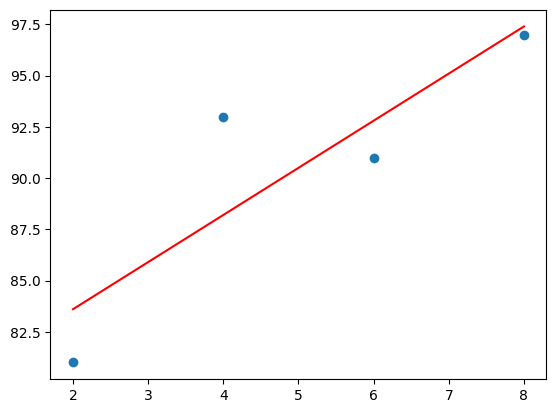

In [9]:
#앞서 구한 최종 a값을 기울기, b값을 y절편에 대입하여 그래프를 그립니다.
y_pred = a * x + b      

#그래프 출력
plt.scatter(x, y)
plt.plot(x, y_pred,'r')
plt.show()

## 4. 파이썬 코딩으로 확인하는 다중 선형 회귀

### 1.환경 준비

In [10]:
import numpy as np
import matplotlib.pyplot as plt

### 2. 데이터 준비

In [11]:
#공부 시간 x1과 과외 시간 x2, 그성적 y의 넘파이 배열을 만듭니다. 
x1 = np.array([2, 4, 6, 8])
x2 = np.array([0, 4, 2, 3])
y = np.array([81, 93, 91, 97]) 

### 3. 데이터 분포 확인

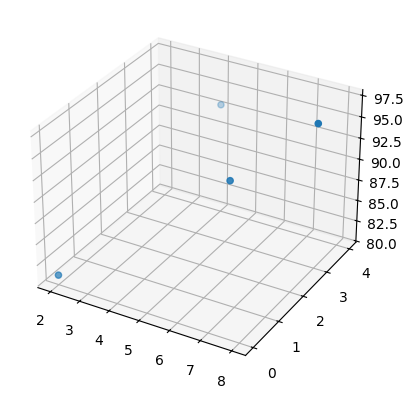

In [12]:
# 데이터의 분포를 그래프로 나타냅니다.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter3D(x1, x2, y)
plt.show()

### 4. 실행을 위한 변수 설정

In [13]:
# 기울기 a와 절편 b의 값을 초기화합니다.
a1 = 0
a2 = 0
b = 0

#학습률을 정합니다.
lr = 0.01 

#몇 번 반복될지를 설정합니다.
epochs = 2001 

### 5. 경사 하강법

In [14]:
# x 값이 총 몇 개인지 셉니다. x1과 x2의 수가 같으므로 x1만 세겠습니다. 
n=len(x1)

#경사 하강법을 시작합니다.
for i in range(epochs):                  # epoch 수 만큼 반복
    
    y_pred = a1 * x1 + a2 * x2 + b       #예측 값을 구하는 식을 세웁니다
    error = y - y_pred                   #실제 값과 비교한 오차를 error로 놓습니다.
    
    a1_diff = (2/n) * sum(-x1 * (error)) # 오차함수를 a1로 편미분한 값입니다. 
    a2_diff = (2/n) * sum(-x2 * (error)) # 오차함수를 a2로 편미분한 값입니다. 
    b_diff = (2/n) * sum(-(error))       # 오차함수를 b로 편미분한 값입니다. 
    
    a1 = a1 - lr * a1_diff  # 학습률을 곱해 기존의 a1 값을 업데이트합니다.
    a2 = a2 - lr * a2_diff  # 학습률을 곱해 기존의 a2 값을 업데이트합니다.
    b = b - lr * b_diff     # 학습률을 곱해 기존의 b 값을 업데이트합니다.
    
    if i % 100 == 0:        # 100번 반복될 때마다 현재의 a1, a2, b 값을 출력합니다.
        print("epoch=%.f, 기울기1=%.04f, 기울기2=%.04f, 절편=%.04f" % (i, a1, a2, b))
        

epoch=0, 기울기1=9.2800, 기울기2=4.2250, 절편=1.8100
epoch=100, 기울기1=9.5110, 기울기2=5.0270, 절편=22.9205
epoch=200, 기울기1=7.3238, 기울기2=4.2950, 절편=37.8751
epoch=300, 기울기1=5.7381, 기울기2=3.7489, 절편=48.7589
epoch=400, 기울기1=4.5844, 기울기2=3.3507, 절편=56.6800
epoch=500, 기울기1=3.7447, 기울기2=3.0608, 절편=62.4448
epoch=600, 기울기1=3.1337, 기울기2=2.8498, 절편=66.6404
epoch=700, 기울기1=2.6890, 기울기2=2.6962, 절편=69.6938
epoch=800, 기울기1=2.3653, 기울기2=2.5845, 절편=71.9160
epoch=900, 기울기1=2.1297, 기울기2=2.5032, 절편=73.5333
epoch=1000, 기울기1=1.9583, 기울기2=2.4440, 절편=74.7103
epoch=1100, 기울기1=1.8336, 기울기2=2.4009, 절편=75.5670
epoch=1200, 기울기1=1.7428, 기울기2=2.3695, 절편=76.1904
epoch=1300, 기울기1=1.6767, 기울기2=2.3467, 절편=76.6441
epoch=1400, 기울기1=1.6286, 기울기2=2.3301, 절편=76.9743
epoch=1500, 기울기1=1.5936, 기울기2=2.3180, 절편=77.2146
epoch=1600, 기울기1=1.5681, 기울기2=2.3092, 절편=77.3895
epoch=1700, 기울기1=1.5496, 기울기2=2.3028, 절편=77.5168
epoch=1800, 기울기1=1.5361, 기울기2=2.2982, 절편=77.6095
epoch=1900, 기울기1=1.5263, 기울기2=2.2948, 절편=77.6769
epoch=2000, 기울기1=1.5191, 기울기2=2.2

In [15]:
#실제 점수와 예측 된 점수를 출력합니다.
print("실제 점수:", y)
print("예측 점수:", y_pred)

실제 점수: [81 93 91 97]
예측 점수: [80.76387645 92.97153922 91.42520875 96.7558749 ]


## 5-1. 텐서플로에서 실행하는 선형 회귀 모델

### 1.환경 준비

In [16]:
import numpy as np
import matplotlib.pyplot as plt

#텐서플로의 케라스 API에서 필요한 함수들을 불러 옵니다.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 2. 데이터 준비

In [17]:
x = np.array([2, 4, 6, 8])
y = np.array([81, 93, 91, 97]) 

### 3. 모델 실행

In [18]:
model = Sequential()

# 출력 값, 입력 변수, 분석 방법에 맞게끔 모델을 설정합니다. 
model.add(Dense(1, input_dim=1, activation='linear'))

# 오차 수정을 위해 경사 하강법(sgd)을, 오차의 정도를 판단하기 위해 평균 제곱 오차(mse)를 사용합니다. 
model.compile(optimizer='sgd', loss='mse')

# 오차를 최소화하는 과정을 2000번 반복합니다.
model.fit(x, y, epochs=2000)

Epoch 1/2000


c:\Users\tom\anaconda3\envs\env_llm\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 7781.4805
Epoch 2/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1976.9136
Epoch 3/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1119.0129
Epoch 4/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 987.6890
Epoch 5/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 963.1157
Epoch 6/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 954.2555
Epoch 7/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 947.7370
Epoch 8/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 941.5964
Epoch 9/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 935.5447
Epoch 10/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 929.5396
Epoch 11/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 923.5743
Epoch 12/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 917.6479
Epoch 13/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 911.7599
Epoch 14/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 905.9100
Epoch 15/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step 

### 4. 그래프로 확인

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


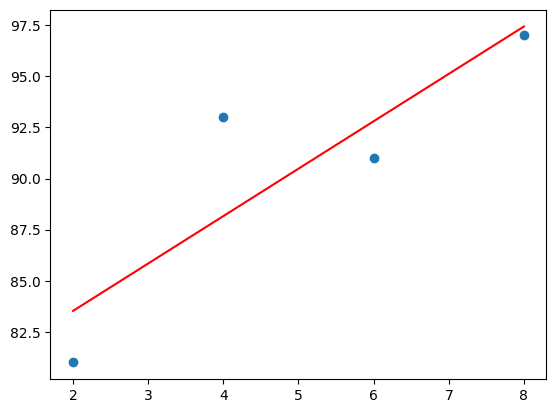

In [19]:
plt.scatter(x, y)
plt.plot(x, model.predict(x),'r')    # 예측 결과를 그래프로 나타냅니다.
plt.show()

### 5. 모델 테스트

In [20]:
#임의의 시간을 집어넣어 점수를 예측하는 모델을 테스트해 보겠습니다.

hour = 7
prediction = model.predict(np.array([hour]))

print("%.f시간을 공부할 경우의 예상 점수는 %.02f점입니다" % (hour, prediction[0][0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
7시간을 공부할 경우의 예상 점수는 95.12점입니다


## 5-2 텐서플로에서 실행하는 다중 선형회귀 모델

### 1.환경 준비

In [21]:
import numpy as np
import matplotlib.pyplot as plt

#텐서플로의 케라스 API에서 필요한 함수들을 불러 옵니다.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 2. 데이터 준비

In [22]:
x = np.array([[2, 0], [4, 4], [6, 2], [8, 3]])
y = np.array([81, 93, 91, 97]) 

### 3. 모델 실행

In [ ]:
model = Sequential()

#입력 변수가 2개(학습 시간, 과외 시간)이므로 input_dim에 2를 입력합니다. 
model.add(Dense(1, input_dim=2, activation='linear'))
model.compile(optimizer='sgd' ,loss='mse')

model.fit(x, y, epochs=2000)

### 4. 모델 테스트

In [ ]:
#임의의 학습 시간과 과외 시간을 집어넣어 점수를 예측하는 모델을 테스트해 보겠습니다.

hour = 7
private_class = 4
prediction = model.predict([[hour, private_class]])

print("%.f시간을 공부하고 %.f시간의 과외를 받을 경우, 예상 점수는 %.02f점입니다" % (hour, private_class, prediction))

### 연습문제

4️⃣ 문제: 온도와 아이스크림 판매량
🧠 문제
x = [10, 15, 20, 25]
y = [100, 150, 200, 250]

👉 x = 30일 때 예측하시오.

📌 설명

온도가 증가하면 판매량이 일정하게 증가하는 선형 관계이다.

✏️ 정답

300

💻 코드
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

x = np.array([10, 15, 20, 25])
y = np.array([100, 150, 200, 250])

model = Sequential()
model.add(Dense(1, input_shape=(1,)))

model.compile(optimizer='sgd', loss='mse')
model.fit(x, y, epochs=500, verbose=0)

print(model.predict([30]))


2️⃣ 문제: 운동 시간과 칼로리
🧠 문제
x = [10, 20, 30, 40]
y = [100, 200, 300, 400]

👉 x = 25일 때 예측하시오.

📌 설명

y = 10x 형태의 완전 비례 관계이다.

✏️ 정답

250

💻 코드
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

x = np.array([10, 20, 30, 40])
y = np.array([100, 200, 300, 400])

model = Sequential()
model.add(Dense(1, input_shape=(1,)))

model.compile(optimizer='sgd', loss='mse')
model.fit(x, y, epochs=500, verbose=0)

print(model.predict([25]))

